### Paso 1. Importar librerías

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

# Librerias para cumplir con la actividad 2
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io

### Paso 2. Descargar el dataset

In [2]:
# Descargar set de datos de Fashion MNIST de Zalando
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\angel\tensorflow_datasets\fashion_mnist\incomplete.X7PDW9_3.0.1\fashion_mnist-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\angel\tensorflow_datasets\fashion_mnist\incomplete.X7PDW9_3.0.1\fashion_mnist-test.tfrecord…

Dataset fashion_mnist downloaded and prepared to C:\Users\angel\tensorflow_datasets\fashion_mnist\3.0.1. Subsequent calls will reuse this data.


#### Escribir a que se refieren los parametros:
as_supervised: Hace que el dataset se cargue en forma de (imagen, etiqueta). Es decir, cada dato viene con su imagen y la categoría correcta, lo cual permite entrenar el modelo.

`bool, if True, the returned tf.data.Dataset will have a 2-tuple structure (input, label) `

with_info: Hace que también se cargue información adicional del dataset, como el número de imágenes, las clases disponibles y otros metadatos.

`bool, if True, tfds.load will return the tuple (tf.data.Dataset, tfds.core.DatasetInfo), the latter containing the info associated with the builder.`

### Paso 3. Imprimir los metadatos

In [4]:
# Imprimir los metadatos para ver la información del set
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\angel\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

### Paso 4. Ordenar cada conjunto de datos en las variables correspondientes

In [5]:
# Obtenemos en variables separadas los datos de entrenamiento (60k) y pruebas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

### Paso 5. Asignar los nombres de las categorías (incluidas en el set) a una variable y mostrarlas.

In [6]:
# Asignar los nombres 10 categorias a una variable
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

### Paso 6. Normalizar los datos.

In [7]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255 # Aqui lo pasa de 0-255 a 0-1
    return imagenes, etiquetas

In [8]:
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#### Escribe para que se utiliza la función __map()__

Se utiliza para aplicar una función a todos los elementos del dataset. 

`En este caso, se usa para aplicar la función normalizar() a todas las imágenes de entrenamiento y de prueba.`

Para que el entrenamiento sea más rápido se recomienda guardar los datos en caché y no utilizar disco, para
ello agregar el siguiente código:

In [9]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

### Paso 7. Mostrar imagenes del dataset.

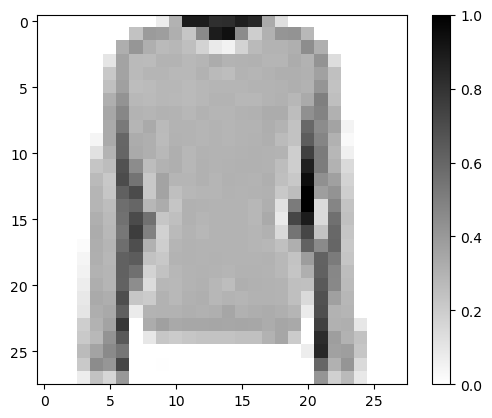

In [10]:
# Mostrar una imagen de los datos de pruebas
for imagen, etiqueta in datos_entrenamiento.take(1):
    break

imagen = imagen.numpy().reshape((28,28)) # Redimensionar los pixeles

# Dibujar
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

Código para mostrar una imagen por cada categoría con su etiqueta

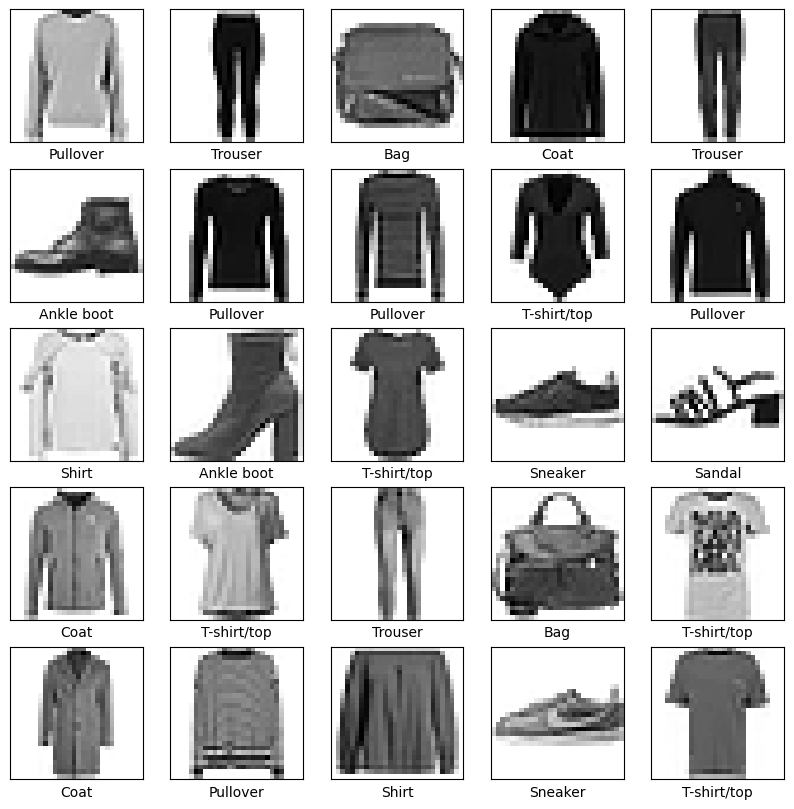

In [11]:
# Mostrar una imagen por cada categoria con su etiqueta
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

### Paso 8. Creación de modelo

- Se utiliza una red de tipo secuencial.
- Se define una capa de entrada de forma manual utilizando la función Flatten(), cuya objetivo es, convertir a una dimensión los datos de entrada. Es decir, la matriz original en 2D de 28x28 se convierte a un vector de 784 neuronas.
- Agregar dos capas ocultas de 50 neuronas cada una y una función de activación ReLU.
- Agregar la capa de salida con 10 neuronas y una función de activación SoftMax, la cuál es muy comúnmente utilizada en redes de clasificación, para que la suma de las neuronas de salidas sólo de cómo resultado 1.


In [12]:
# Crear el modelo
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)), # blanco y negro
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) # Para redes de clasificacion
])

c:\Users\angel\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Paso 9. Compilar el modelo

In [13]:
# Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### Paso 10. Dividir por lotes

In [14]:
TAMANO_LOTE = 32

In [15]:
# Los numeros de datos en entrenamiento y pruebas (60k y 10k)
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples

print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


Ajustar las propiedades de los datos de entrenamiento y prueba. La intención es que el entrenamiento se
realice de forma aleatoria, debido a que realizará varias veces el recorrido, para ello se implementa la función
repeat() y shuffle(). Esto evita que la red aprenda en orden secuencial.

In [16]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

### Paso 11. Entrenar el modelo

In [17]:
# Entrenando el modelo
historial = modelo.fit(
    datos_entrenamiento,
    epochs=5,
    steps_per_epoch=math.ceil(num_ej_entrenamiento/TAMANO_LOTE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8122 - loss: 0.5276
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8603 - loss: 0.3853
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8713 - loss: 0.3519
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8800 - loss: 0.3291
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8837 - loss: 0.3102


### Paso 12. Mostrar los datos de la función de perdida

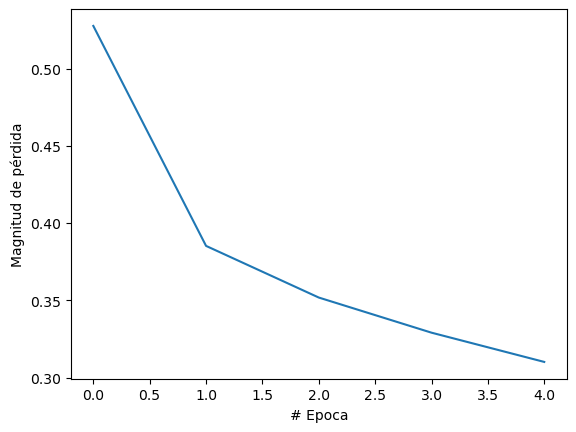

In [18]:
# Ver la funcion de perdida
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

### Paso 13. Realizar predicciones

Imprimir 25 imágenes del set de prueba y realice la predicción de la categoría a la que pertenece cada una de
esas imágenes. Identificar con una barra azul si la predicción es correcta o roja si es incorrecta

In [19]:
# Crear una cuadricula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)

    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(
        nombres_clases[etiqueta_prediccion],
        100*np.max(arr_predicciones),
        nombres_clases[etiqueta_real]),
        color=color
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


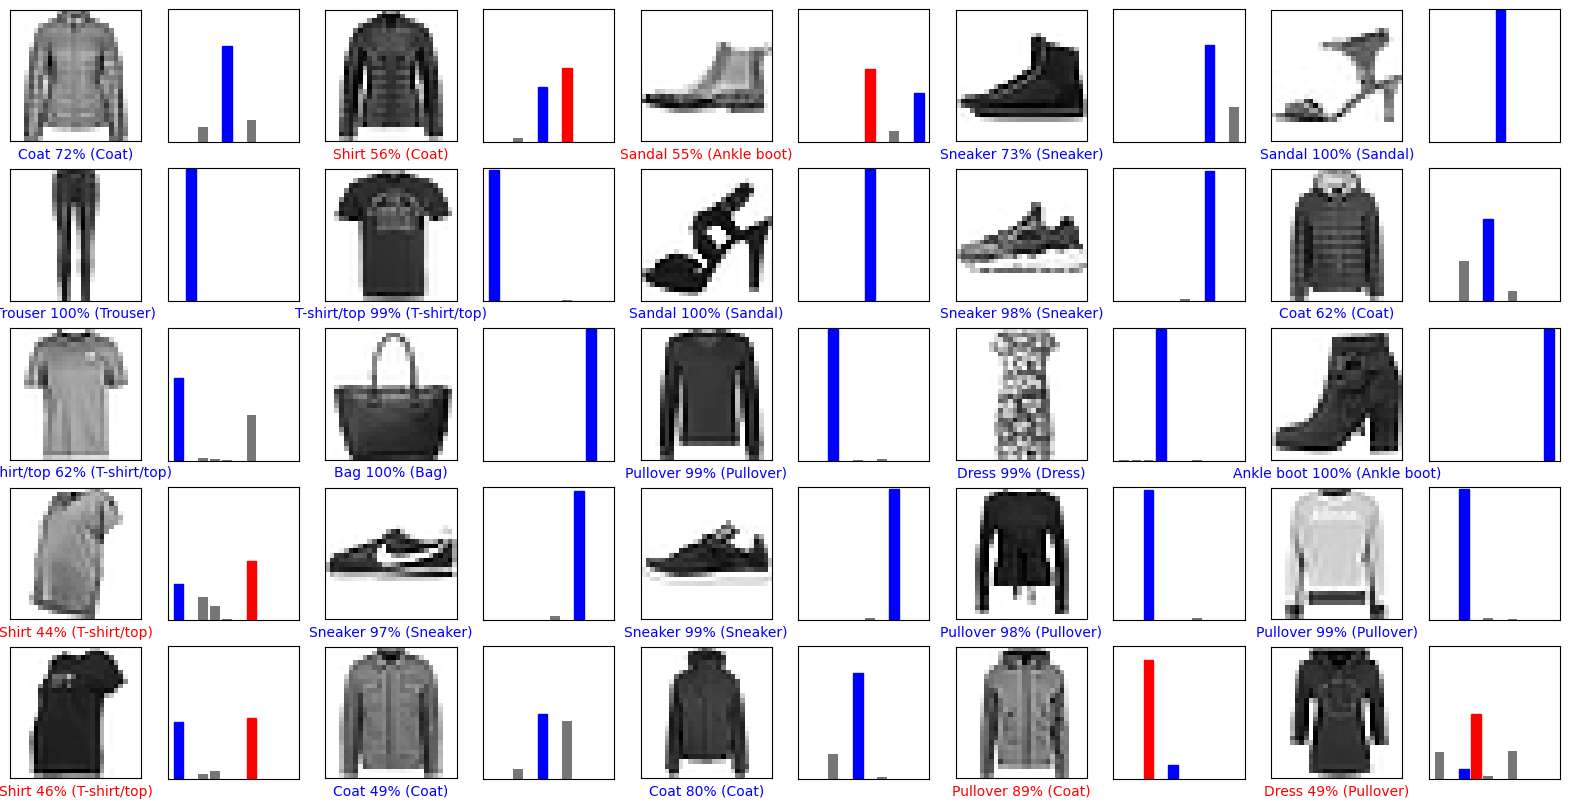

In [20]:
def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0,1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

Realizar la predicción de una imagen

In [23]:
# Realizar la predicción de una imagen
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediccion: Dress


### Actividad 2
### **cargar imagen**

In [41]:
uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

### **preprocesar**

In [42]:
def preprocesar_imagen_usuario(contenido):
    img = Image.open(io.BytesIO(contenido)).convert('L')  # escala de grises
    img = img.resize((28, 28))
    img_array = np.array(img).astype('float32') / 255.0

    # Invertir colores si la prenda está oscura sobre fondo claro
    img_array = 1.0 - img_array

    # Mostrar imagen procesada
    plt.figure(figsize=(3,3))
    plt.imshow(img_array, cmap='gray')
    plt.title("Imagen procesada")
    plt.axis('off')
    plt.show()

    # Dar formato para el modelo
    img_array = img_array.reshape(1, 28, 28, 1)
    return img_array

### **clasificar**

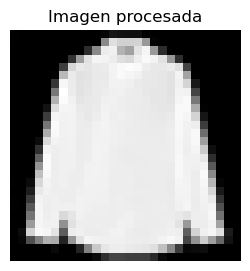

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicción: Shirt
Confianza: 85.00%


In [43]:
if len(uploader.value) > 0:
    archivo = uploader.value[0]


    contenido = archivo['content']

    imagen_usuario = preprocesar_imagen_usuario(contenido)
    prediccion = modelo.predict(imagen_usuario)

    indice = np.argmax(prediccion[0])
    confianza = np.max(prediccion[0]) * 100

    print("Predicción:", nombres_clases[indice])
    print("Confianza: {:.2f}%".format(confianza))
else:
    print("Primero sube una imagen en la celda anterior.")

### **exportación a h5**

El formato .h5 es un tipo de archivo basado en HDF5 que permite almacenar modelos de aprendizaje automático. Sirve para guardar la estructura del modelo, sus pesos y, en algunos casos, la configuración de entrenamiento.

In [44]:
modelo.save("modelo_tienda_ropa.h5")
print("Modelo exportado correctamente en formato .h5")

Modelo exportado correctamente en formato .h5
